# Run cells from AllenDB

In [1]:
import os, sys, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def _is_scp_repo_root(path: Path) -> bool:
    return (path / 'modules_local').is_dir() and (path / 'run_pipeline.py').is_file()


def _find_scp_repo_root(start=None) -> Path:
    env_root = os.environ.get('SCP_ROOT')
    if env_root:
        env_path = Path(env_root).expanduser().resolve()
        if _is_scp_repo_root(env_path):
            return env_path
        raise FileNotFoundError(
            f"SCP_ROOT does not point to an SCP repo root: {env_path}. "
            "Expected modules_local/ and run_pipeline.py."
        )

    start = (start or Path.cwd()).resolve()
    for cand in (start, *start.parents):
        if _is_scp_repo_root(cand):
            return cand

    # Also support kernels launched from a parent directory of the repo.
    for base in (start, start.parent):
        try:
            for child in base.iterdir():
                if child.is_dir() and _is_scp_repo_root(child):
                    return child.resolve()
        except Exception:
            pass

    raise FileNotFoundError(
        f'Could not locate SCP repo root from {start}. '
        'Set SCP_ROOT or launch Jupyter from inside the repo.'
    )


def _resolve_external_repo(
    repo_name: str,
    marker_rel: Path,
    env_vars: tuple[str, ...],
    repo_root: Path,
) -> Path:
    candidates: list[Path] = []
    for var in env_vars:
        raw = os.environ.get(var)
        if raw:
            candidates.append(Path(raw).expanduser())

    candidates.extend(
        [
            repo_root.parent / 'mods' / repo_name,
            repo_root / 'mods' / repo_name,
            Path.home() / 'mods' / repo_name,
            (Path.cwd() / '..' / 'mods' / repo_name).resolve(),
            (Path.cwd() / 'mods' / repo_name).resolve(),
        ]
    )

    seen: set[Path] = set()
    for cand in candidates:
        try:
            resolved = cand.resolve()
        except Exception:
            resolved = cand
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / marker_rel).is_file():
            return resolved

    raise FileNotFoundError(
        f"{repo_name} repo not found. Set {', '.join(env_vars)} or place it at ../mods/{repo_name} relative to SCP."
    )


# Ensure SCP repo root is importable
repo_root = _find_scp_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Import SCP modules used by this notebook
from modules_local import run_sim

# Import ACT modules (read-only external dependency)
act_path = _resolve_external_repo(
    repo_name='ACT',
    marker_rel=Path('act') / 'passive.py',
    env_vars=('SCP_ACT_PATH', 'ACT_PATH', 'ACT_ROOT'),
    repo_root=repo_root,
)
if str(act_path) not in sys.path:
    sys.path.append(str(act_path))

from act.passive import ACTPassiveModule


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


# Local Cell Bundle

### Validate Local Cell Bundle (prepared in Step 0)

In [2]:
cell_name = 'PV' #SST, SST_0, PV, PN
model_dir = 'seg_tuned' #'seg_tuned'

cell_dir = repo_root / 'cells' / cell_name
if not cell_dir.is_dir():
    raise FileNotFoundError(f"Cell directory not found: {cell_dir}")
os.chdir(cell_dir)
print('CWD:', Path.cwd())

cfg_path = Path('tunes') / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path('tunes') / model_dir / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = repo_root / 'cells' / cell_name / 'tunes' / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = repo_root / 'cells' / cell_name / 'tunes' / model_dir / "sim_config.json"
if cfg_path.is_file():
    sim_cfg_preview = json.loads(cfg_path.read_text())


bundle_dir = Path('tunes') / model_dir
required_paths = [
    bundle_dir / "manifest.json",
    bundle_dir / "modfiles",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    missing_text = "\n".join(missing)
    raise FileNotFoundError(
        f"Missing required local cell bundle files:\n{missing_text}\n"
        "Prepare/download the bundle in Step 0, then rerun this notebook."
    )

print(f"Using existing local model bundle: {bundle_dir.resolve()}")


CWD: /home/hrbncv/SCP/cells/PV
Using existing local model bundle: /home/hrbncv/SCP/cells/PV/tunes/seg_tuned


### Load Precompiled Mechanisms (from Step 0)

In [3]:
tune_dir = repo_root / 'cells' / cell_name / 'tunes' / model_dir
if not tune_dir.is_dir():
    raise FileNotFoundError(f"Tune directory not found: {tune_dir}")
os.chdir(tune_dir)

from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()

mech_candidates = [
    Path("modfiles/x86_64/.libs/libnrnmech.so"),
    Path("modfiles/x86_64/libnrnmech.so"),
]

mech_path = next((p for p in mech_candidates if p.is_file()), None)
if mech_path is None:
    raise FileNotFoundError(
        "Could not find compiled NEURON mechanisms. Expected one of: "
        + ", ".join(str(p) for p in mech_candidates)
        + "\nRun Step 0 to compile modfiles, or use the Colab notebook variant that bootstraps compilation."
    )

h.nrn_load_dll(str(mech_path))
print(f"Loaded mechanisms: {mech_path}")


Loaded mechanisms: modfiles/x86_64/.libs/libnrnmech.so


# Build the cell

In [4]:
from modules_local.notebook_helpers import (
    build_cell_for_notebook,
    resolve_cell_config_for_notebook,
)

cell_config_for_build = resolve_cell_config_for_notebook(cell_name)
cell = build_cell_for_notebook(cell_config_for_build)

sect = cell.h.soma[0]
seg = 0.5
print(f"{sect}: A={round(sect(seg).area(),2)} | D={round(sect.diam)} | L={round(sect.L)}")


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from manifest.json, soma_diam_multiplier=6.0, Vinit=-71.0, loader=allensdk_default
soma[0]: A=4017.88 | D=88 | L=15


# Passive properties

In [5]:
# Soma area from the previous cell
computed_soma_area = cell.h.soma[0](0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 98.9 * 10e6    # (to Ohm from MOhm)
user_provided_tau = 5.9 * 1e-3     # (to s from ms)
user_provided_Vrest = -71.25        # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, 1*computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=0.14847700164342945, g_bar_leak=2.5165593498886345e-05, e_rev_leak=-71.25, g_bar_h=None)


### set simulation parameters

na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                  

         ^


Loaded Allen cell for 'PV' from manifest.json, soma_diam_multiplier=6.0, Vinit=-71.0, loader=allensdk_default
dict_keys(['pas.i', 'Ca_HVA.ica', 'Ca_LVA.ica', 'Ih.ihcn', 'Im_v2.ik', 'Kd.ik', 'K_T.ik', 'Kv2like.ik', 'Kv3_1.ik', 'Nap.ina', 'NaTa.ina', 'SK.ik'])
-50 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in_rest_to_final=95.26864678581347, tau_rest_to_trough=5.6000000000000005, tau_avg=5.6000000000000005, sag_ratio=0.0, V_rest=-71.00131236571643)

-100 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in_rest_to_final=95.26864678581347, tau_rest_to_trough=5.6000000000000005, tau_avg=5.6000000000000005, sag_ratio=0.0, V_rest=-71.00131236571643)



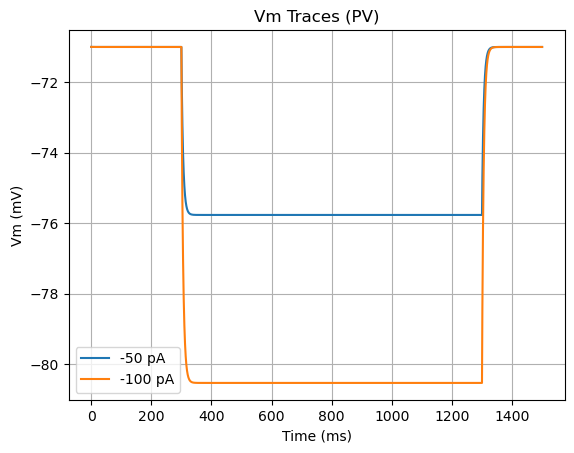

(<matplotlib.legend.Legend at 0x7f00f5951f10>, None, None)

In [6]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 300,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
sim_amps = [-50,-100]

from modules_local.notebook_helpers import build_cell_for_notebook
cell = build_cell_for_notebook(cell_config_for_build)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)
print(looped_records['I'][sim_amps[0]].keys())

# Analyze and plot each run
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        # print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name})")
# plt.xlim(250,800)
# plt.ylim(-80,40)
plt.legend(),plt.grid(),plt.show()

